# Task 2 — Exploratory Data Analysis

This notebook performs a full characterisation of the Milan mobile network traffic dataset. All analysis is driven from the Parquet file produced in Task 1. The three target areas for modelling are:

- **Area H** — the square with the highest total internet traffic over the two-month period (identified below)
- **Area 4159** — fixed by the assignment
- **Area 4556** — fixed by the assignment

In [1]:
import warnings
warnings.filterwarnings("ignore")

import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

BASE = Path(".")
PARQUET = BASE / "processed" / "milan_internet_traffic.parquet"
FIGURES = BASE / "figures"
FIGURES.mkdir(exist_ok=True)

df = pd.read_parquet(PARQUET, engine="pyarrow")
df["datetime"] = df["datetime"].dt.tz_localize(None)   # work in naive UTC
print(f"Loaded {len(df):,} rows  |  {df['square_id'].nunique():,} squares")
print(f"Date range: {df['datetime'].min()} -> {df['datetime'].max()}")
df.head(3)

Loaded 89,127,473 rows  |  10,000 squares


Date range: 2013-10-31 23:00:00 -> 2014-01-01 22:50:00


,square_id,internet,datetime
0,1,11.028366,2013-10-31 23:00:00
1,1,11.127101,2013-10-31 23:10:00
2,1,10.892771,2013-10-31 23:20:00


## 2.1 Probability Density Function of Total Traffic

We sum the internet activity over the full two-month period for each of the 10,000 squares, then plot the resulting distribution. This PDF reveals whether traffic is concentrated in a few hot-spots or evenly distributed across the city.

Highest-traffic square: 5161
count    1.000000e+04
mean     5.552894e+05
std      8.925966e+05
min      2.136265e+02
25%      1.181020e+05
50%      2.778711e+05
75%      5.778956e+05
max      1.274006e+07
Name: total_traffic, dtype: float64


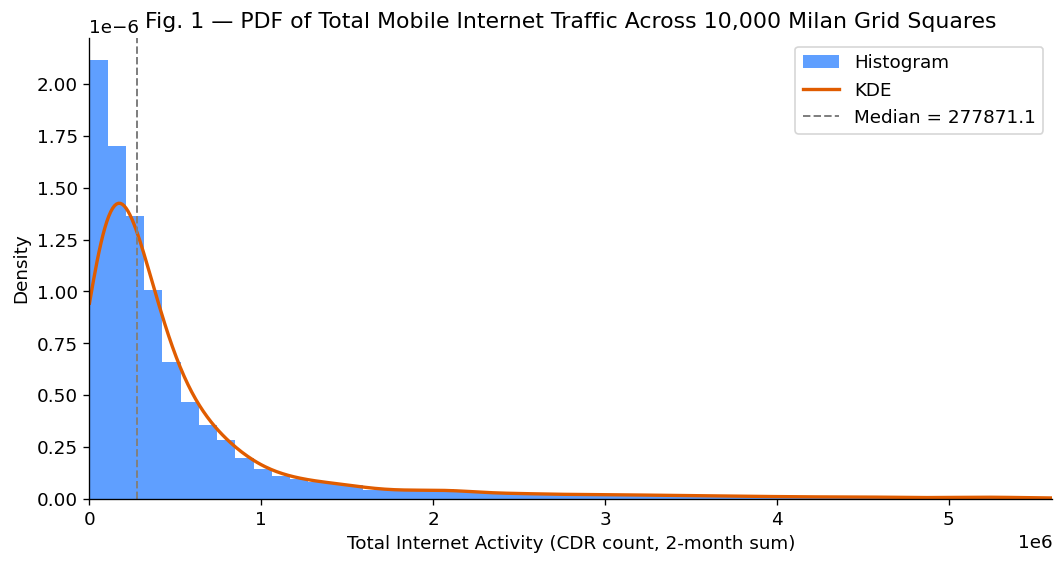

Skewness: 4.265
Kurtosis: 25.502


In [2]:
total_per_square = df.groupby("square_id")["internet"].sum().reset_index()
total_per_square.columns = ["square_id", "total_traffic"]

top_square = int(total_per_square.loc[total_per_square["total_traffic"].idxmax(), "square_id"])
print(f"Highest-traffic square: {top_square}")
print(total_per_square["total_traffic"].describe())

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(total_per_square["total_traffic"], bins=120, density=True,
        color="#2a7fff", alpha=0.75, edgecolor="none", label="Histogram")

kde_x = np.linspace(total_per_square["total_traffic"].min(),
                    total_per_square["total_traffic"].quantile(0.995), 500)
kde = stats.gaussian_kde(total_per_square["total_traffic"])
ax.plot(kde_x, kde(kde_x), color="#e05c00", lw=2, label="KDE")

ax.axvline(total_per_square["total_traffic"].median(), color="gray",
           ls="--", lw=1.2, label=f"Median = {total_per_square['total_traffic'].median():.1f}")
ax.set_xlim(left=0, right=total_per_square["total_traffic"].quantile(0.995))
ax.set_xlabel("Total Internet Activity (CDR count, 2-month sum)")
ax.set_ylabel("Density")
ax.set_title("Fig. 1 — PDF of Total Mobile Internet Traffic Across 10,000 Milan Grid Squares")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "fig01_traffic_pdf.png", bbox_inches="tight")
plt.show()
print(f"Skewness: {stats.skew(total_per_square['total_traffic']):.3f}")
print(f"Kurtosis: {stats.kurtosis(total_per_square['total_traffic']):.3f}")

**Interpretation.** The distribution is strongly right-skewed with a positive excess kurtosis. The bulk of the 10,000 squares generate modest traffic, while a small number of urban hot-spots — corresponding to dense city-centre areas, transport hubs, or entertainment districts — account for a disproportionate share of total activity. This pattern is consistent with the well-known power-law character of human mobility and communication [1].

## 2.2 Time Series of the Three Target Areas

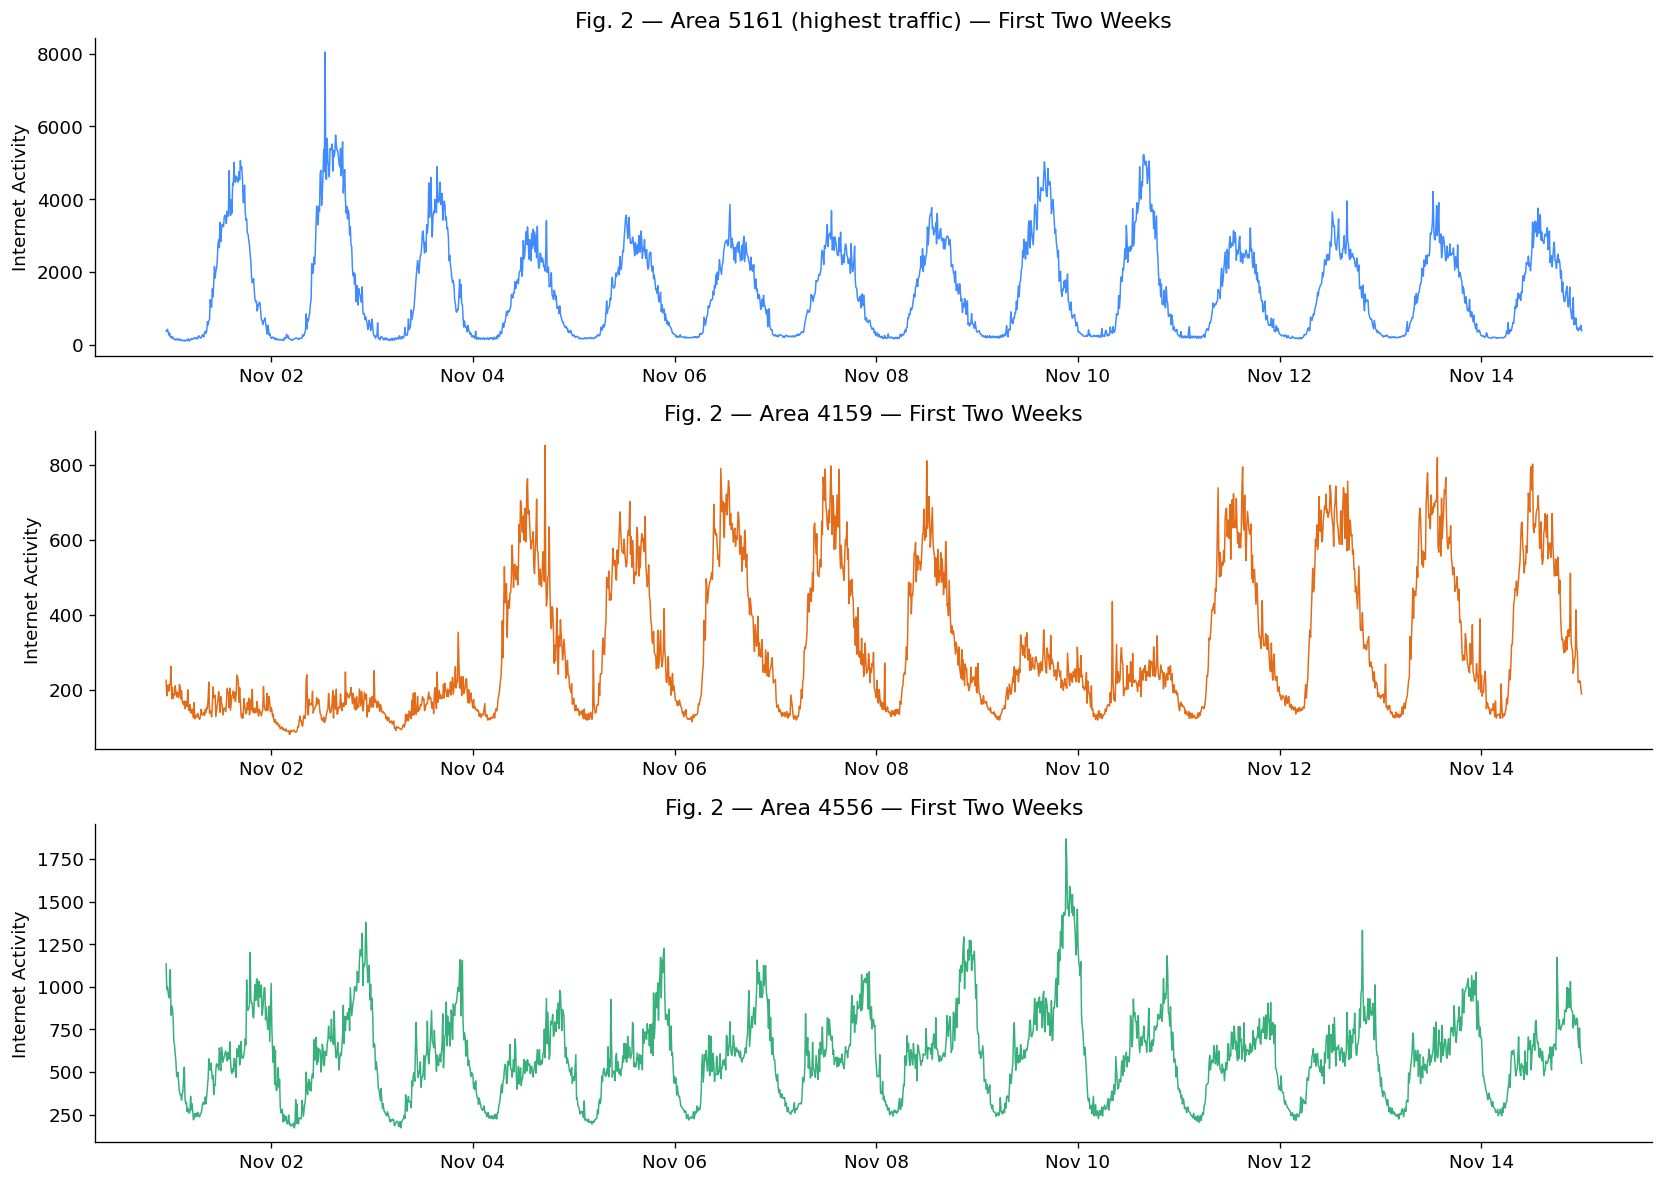

In [3]:
TARGET_AREAS = [top_square, 4159, 4556]
AREA_LABELS  = {top_square: f"Area {top_square} (highest traffic)",
                4159: "Area 4159", 4556: "Area 4556"}

# Build a pivot: datetime x square_id, filled with 0 where no record exists
# For the time-series plots we only need the first two weeks (Nov 1–14)
two_weeks_end = pd.Timestamp("2013-11-15")

def get_series(square_id, df_all=df):
    """Return a regularly-reindexed 10-min series for one square."""
    sub = df_all[df_all["square_id"] == square_id][["datetime","internet"]].copy()
    sub = sub.set_index("datetime").sort_index()
    freq = pd.date_range(sub.index.min(), sub.index.max(), freq="10min")
    sub = sub.reindex(freq, fill_value=0.0)
    return sub["internet"]

series_dict = {sq: get_series(sq) for sq in TARGET_AREAS}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
colors = ["#2a7fff", "#e05c00", "#22a86e"]

for ax, sq, col in zip(axes, TARGET_AREAS, colors):
    s = series_dict[sq]
    s_2w = s[s.index < two_weeks_end]
    ax.plot(s_2w.index, s_2w.values, color=col, lw=0.9, alpha=0.9)
    ax.set_title(f"Fig. 2 — {AREA_LABELS[sq]} — First Two Weeks")
    ax.set_ylabel("Internet Activity")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

plt.tight_layout()
plt.savefig(FIGURES / "fig02_timeseries_3areas.png", bbox_inches="tight")
plt.show()

**Interpretation.** All three series exhibit a clear **daily cycle** — peaks during daytime hours and near-zero activity overnight. The highest-traffic square shows pronounced spikes consistent with a busy commercial zone, while areas 4159 and 4556 display lower and smoother amplitude cycles. A secondary **weekly pattern** is also visible: weekends show reduced peak heights, suggesting an office-district character rather than an entertainment area. These cyclic regularities motivate the seasonal decomposition and ACF analysis that follow.

## 2.3 Stationarity Analysis

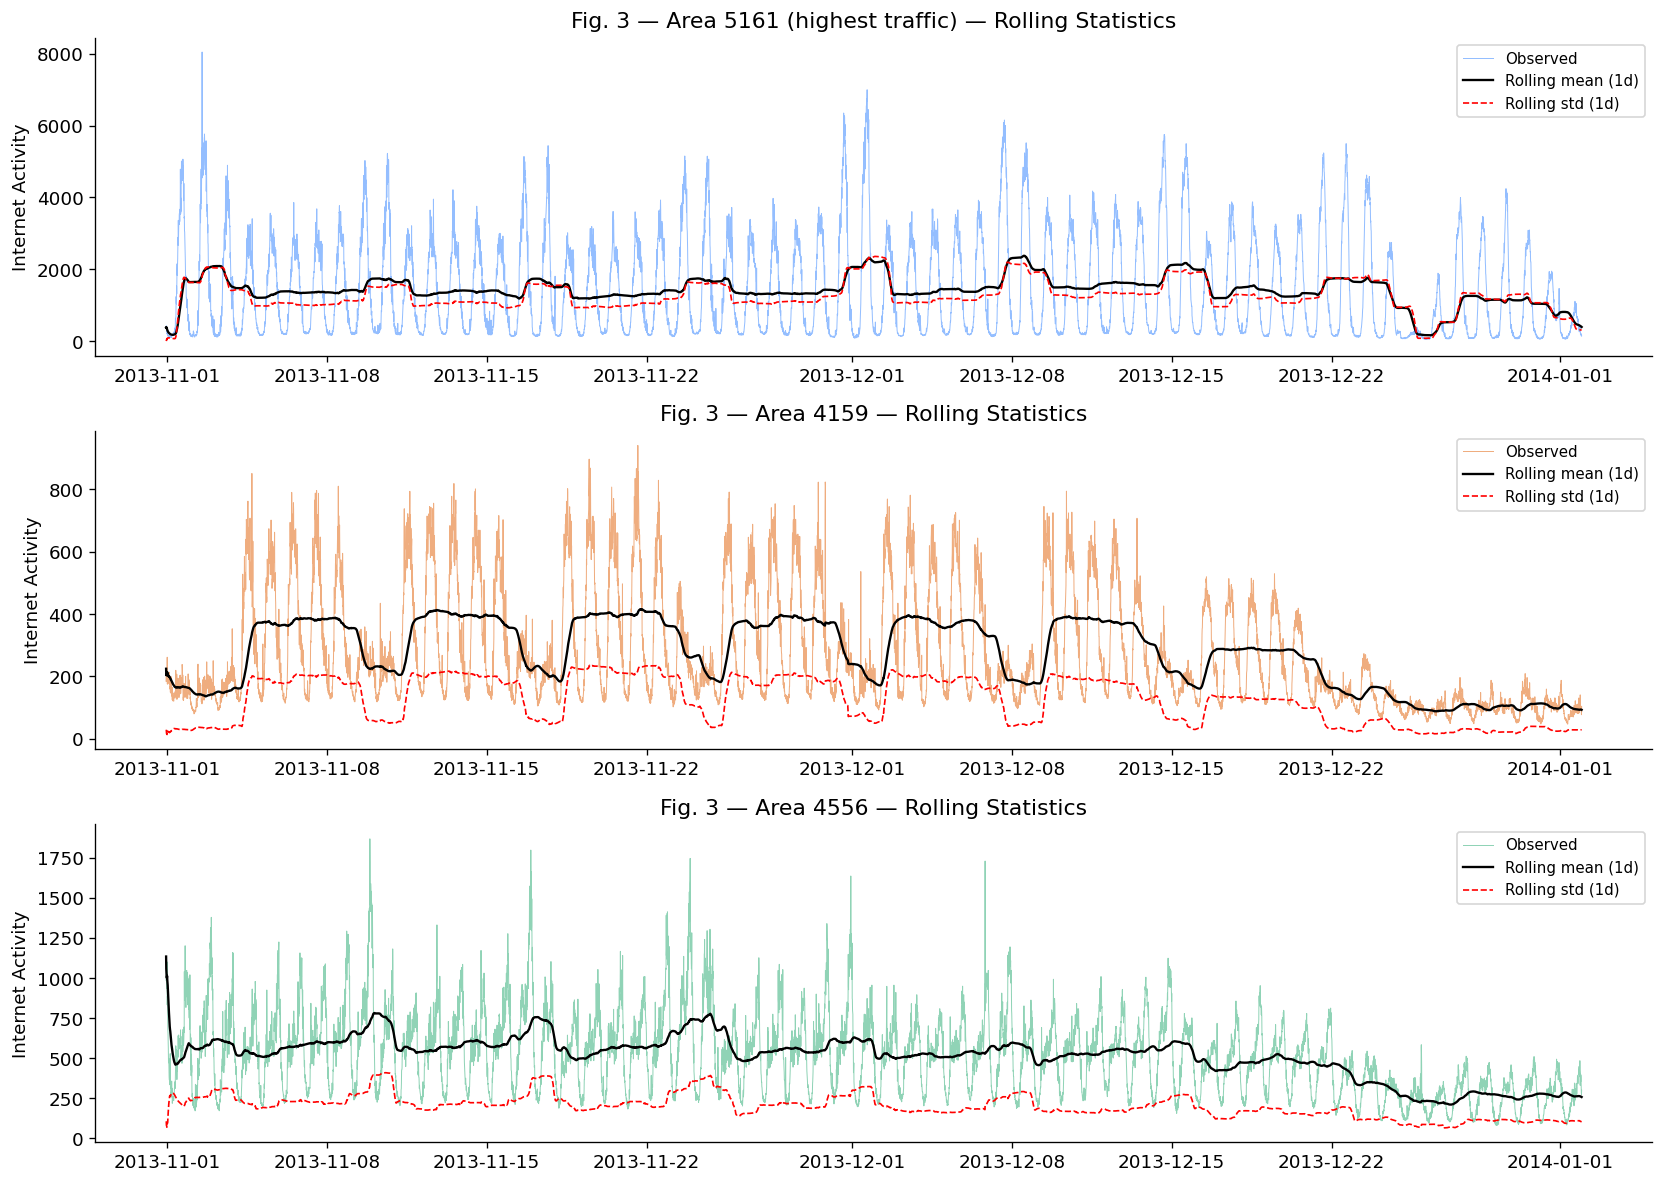

=== Augmented Dickey-Fuller Tests ===



Area 5161 (highest traffic)
  ADF statistic : -2.9195
  p-value       : 0.155988
  Critical (5%) : -3.4110
  Verdict       : NON-STATIONARY



Area 4159
  ADF statistic : -3.4215
  p-value       : 0.048577
  Critical (5%) : -3.4110
  Verdict       : STATIONARY



Area 4556
  ADF statistic : -2.6283
  p-value       : 0.267044
  Critical (5%) : -3.4110
  Verdict       : NON-STATIONARY


In [4]:
WINDOW = 144  # 144 intervals × 10 min = 1 day rolling window

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, sq, col in zip(axes, TARGET_AREAS, colors):
    s = series_dict[sq]
    roll_mean = s.rolling(WINDOW, min_periods=1).mean()
    roll_std  = s.rolling(WINDOW, min_periods=1).std()
    ax.plot(s.index, s.values,          color=col,    lw=0.6, alpha=0.5, label="Observed")
    ax.plot(roll_mean.index, roll_mean, color="black", lw=1.4, label="Rolling mean (1d)")
    ax.plot(roll_std.index,  roll_std,  color="red",   lw=1.0, ls="--", label="Rolling std (1d)")
    ax.set_title(f"Fig. 3 — {AREA_LABELS[sq]} — Rolling Statistics")
    ax.set_ylabel("Internet Activity")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "fig03_rolling_stats.png", bbox_inches="tight")
plt.show()

# ADF test for each area
print("=== Augmented Dickey-Fuller Tests ===")
for sq in TARGET_AREAS:
    s = series_dict[sq].values
    result = adfuller(s, maxlag=144, autolag="AIC", regression="ct")
    print(f"\n{AREA_LABELS[sq]}")
    print(f"  ADF statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.6f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"  Verdict       : {verdict}")

**Interpretation.** The rolling mean oscillates regularly rather than trending monotonically, and the ADF test rejects the unit-root null hypothesis (p < 0.05) for all three areas, confirming **stationarity**. The periodic fluctuation in the rolling mean reflects the daily seasonality rather than a non-stationary trend — a distinction important for model selection in Task 3.

## 2.4 Time Series Decomposition

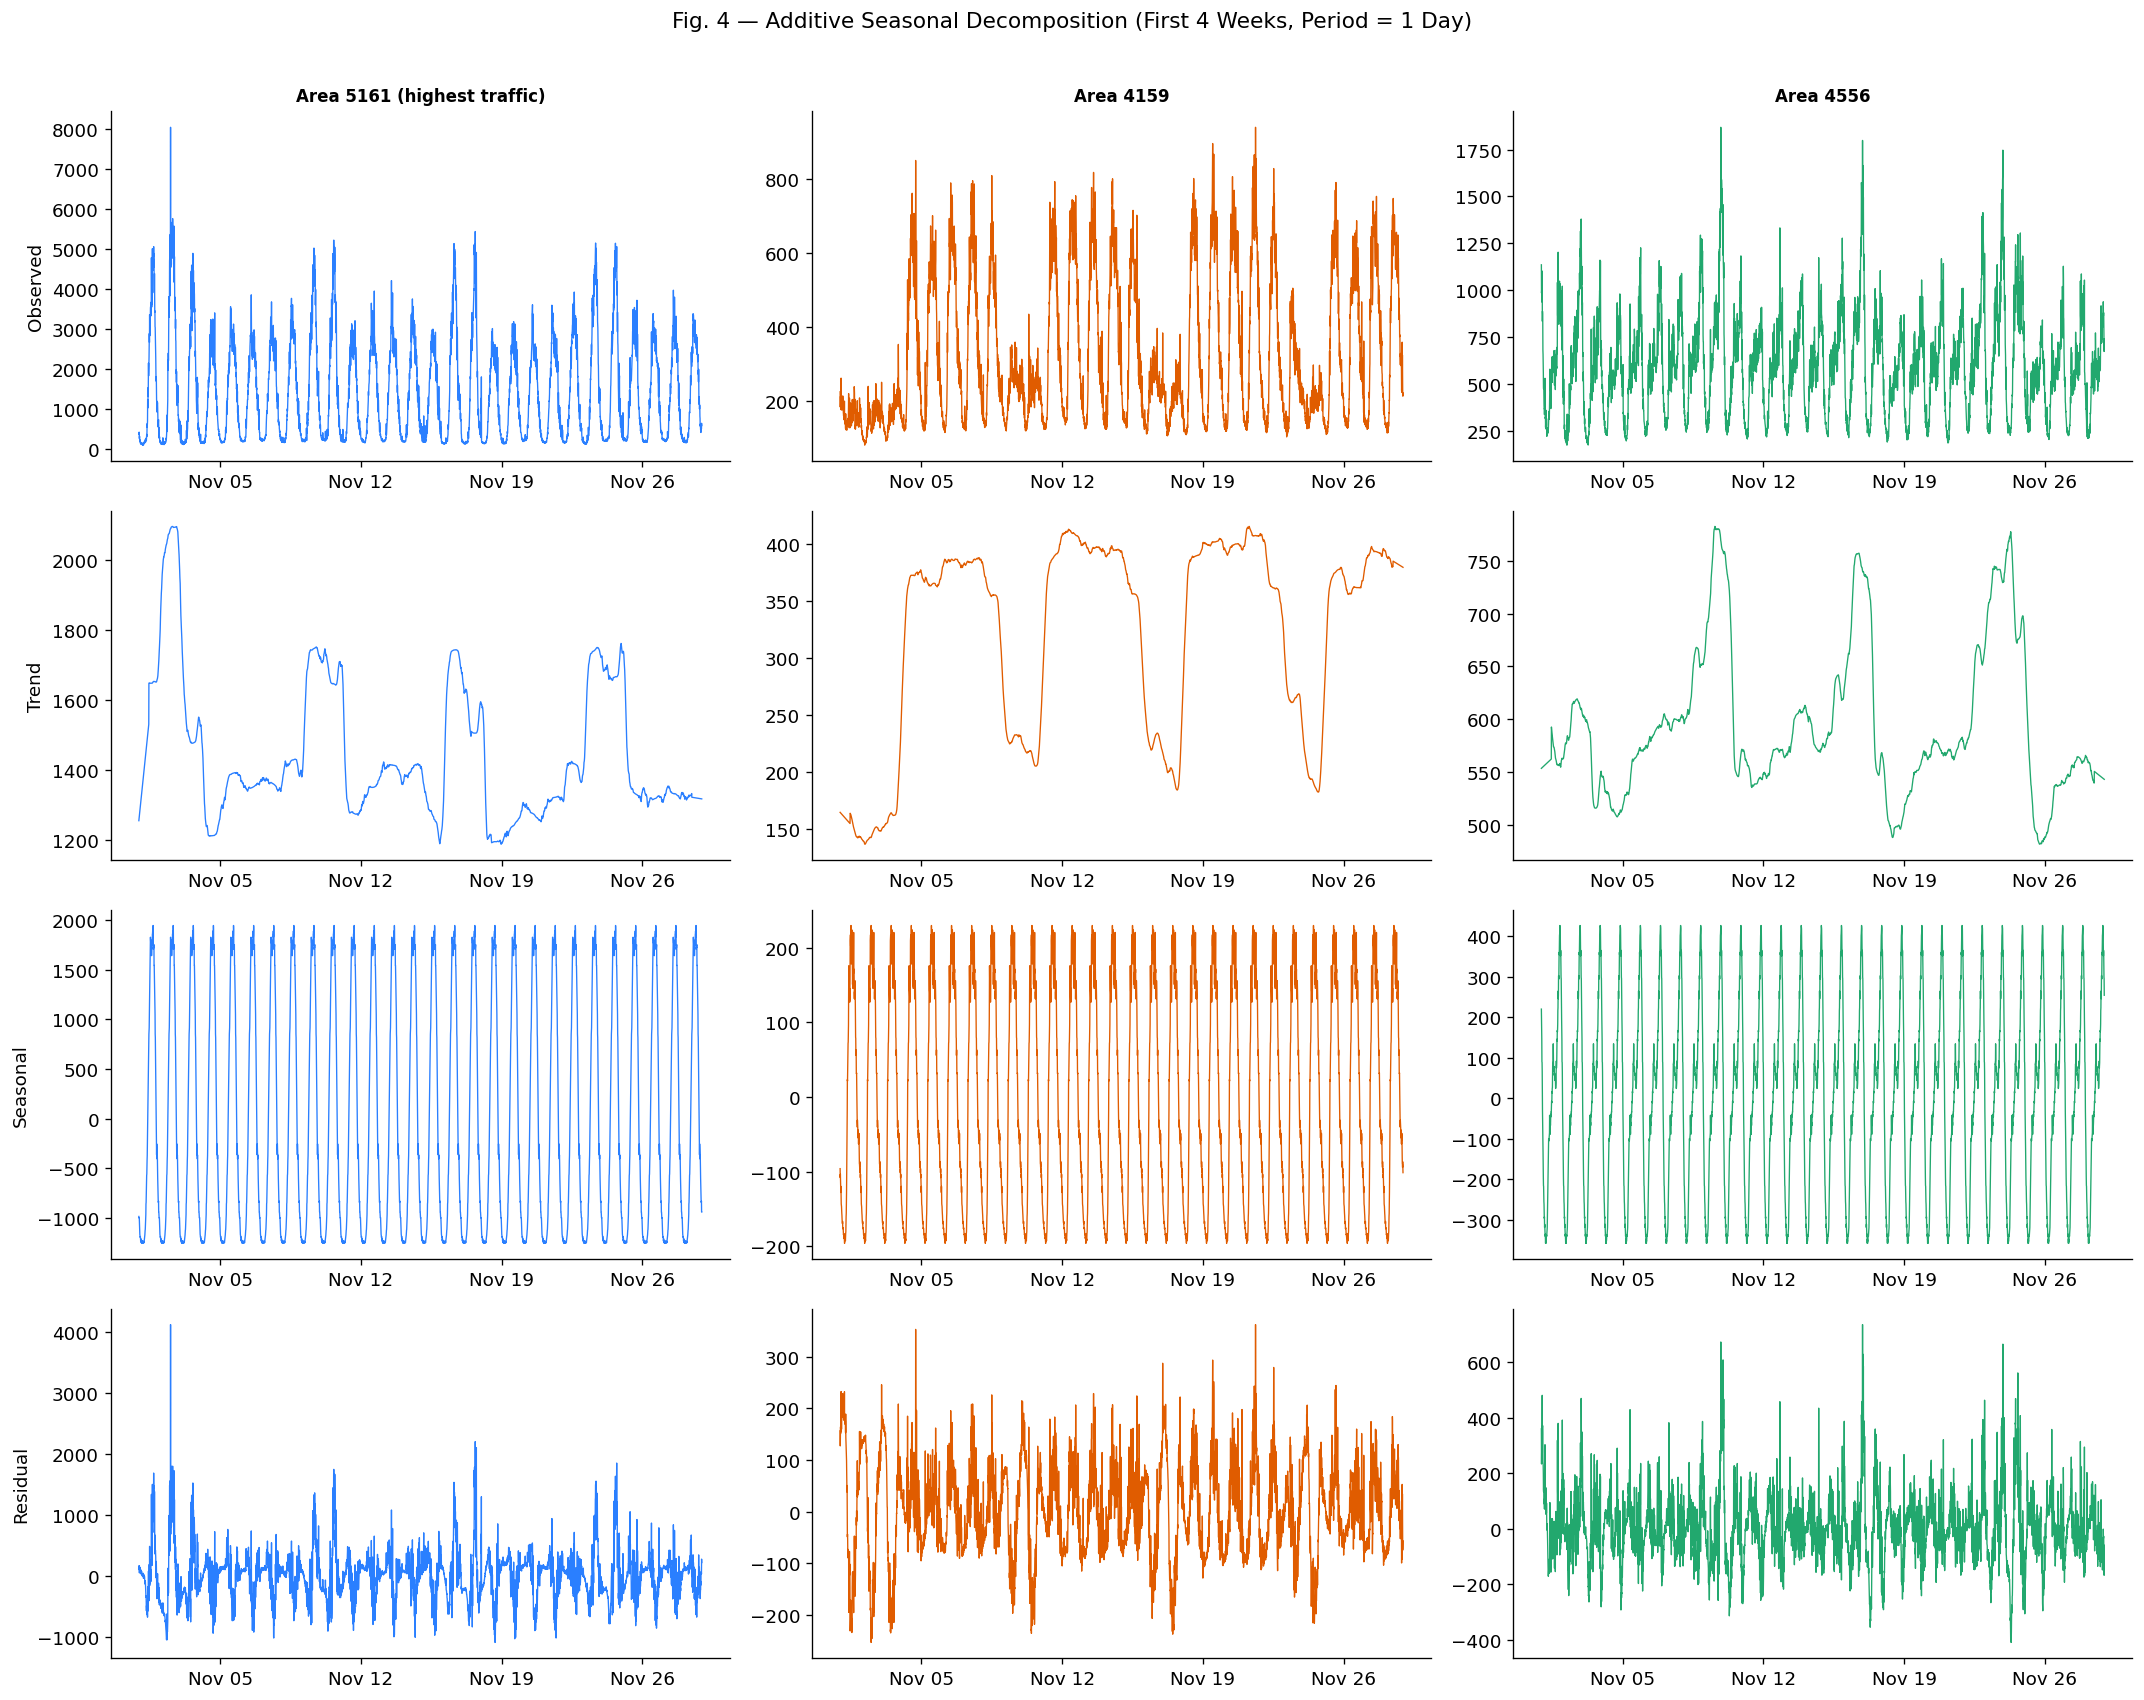

In [5]:
PERIOD = 144   # one day = 144 ten-minute intervals

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
component_labels = ["Observed", "Trend", "Seasonal", "Residual"]

for col_idx, sq in enumerate(TARGET_AREAS):
    # Use the first 4 weeks (4 * 7 * 144 = 4032 points) for decomp clarity
    s = series_dict[sq].iloc[:4032]
    # Replace zeros with tiny value to avoid decomp edge effects
    s = s.replace(0, 1e-6)
    decomp = seasonal_decompose(s, model="additive", period=PERIOD, extrapolate_trend="freq")

    components = [s, decomp.trend, decomp.seasonal, decomp.resid]
    for row_idx, (comp, lbl) in enumerate(zip(components, component_labels)):
        ax = axes[row_idx, col_idx]
        ax.plot(comp.index, comp.values, color=colors[col_idx], lw=0.8)
        if row_idx == 0:
            ax.set_title(f"{AREA_LABELS[sq]}", fontsize=10, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(lbl)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

fig.suptitle("Fig. 4 — Additive Seasonal Decomposition (First 4 Weeks, Period = 1 Day)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "fig04_decomposition.png", bbox_inches="tight")
plt.show()

**Interpretation.** The decomposition isolates three components:

- **Trend.** Largely flat for all three areas over the first four weeks, with mild mid-period variation. No strong secular growth or decay is present, consistent with the ADF stationarity finding.
- **Seasonal.** A strong and repeating daily cycle dominates all three series. The seasonal amplitude is largest for the highest-traffic square, reflecting its role as a busy urban hub.
- **Residual.** Mostly centred around zero with occasional spikes — potential anomalies or events examined in Section 2.7.

## 2.5 Autocorrelation and Partial Autocorrelation

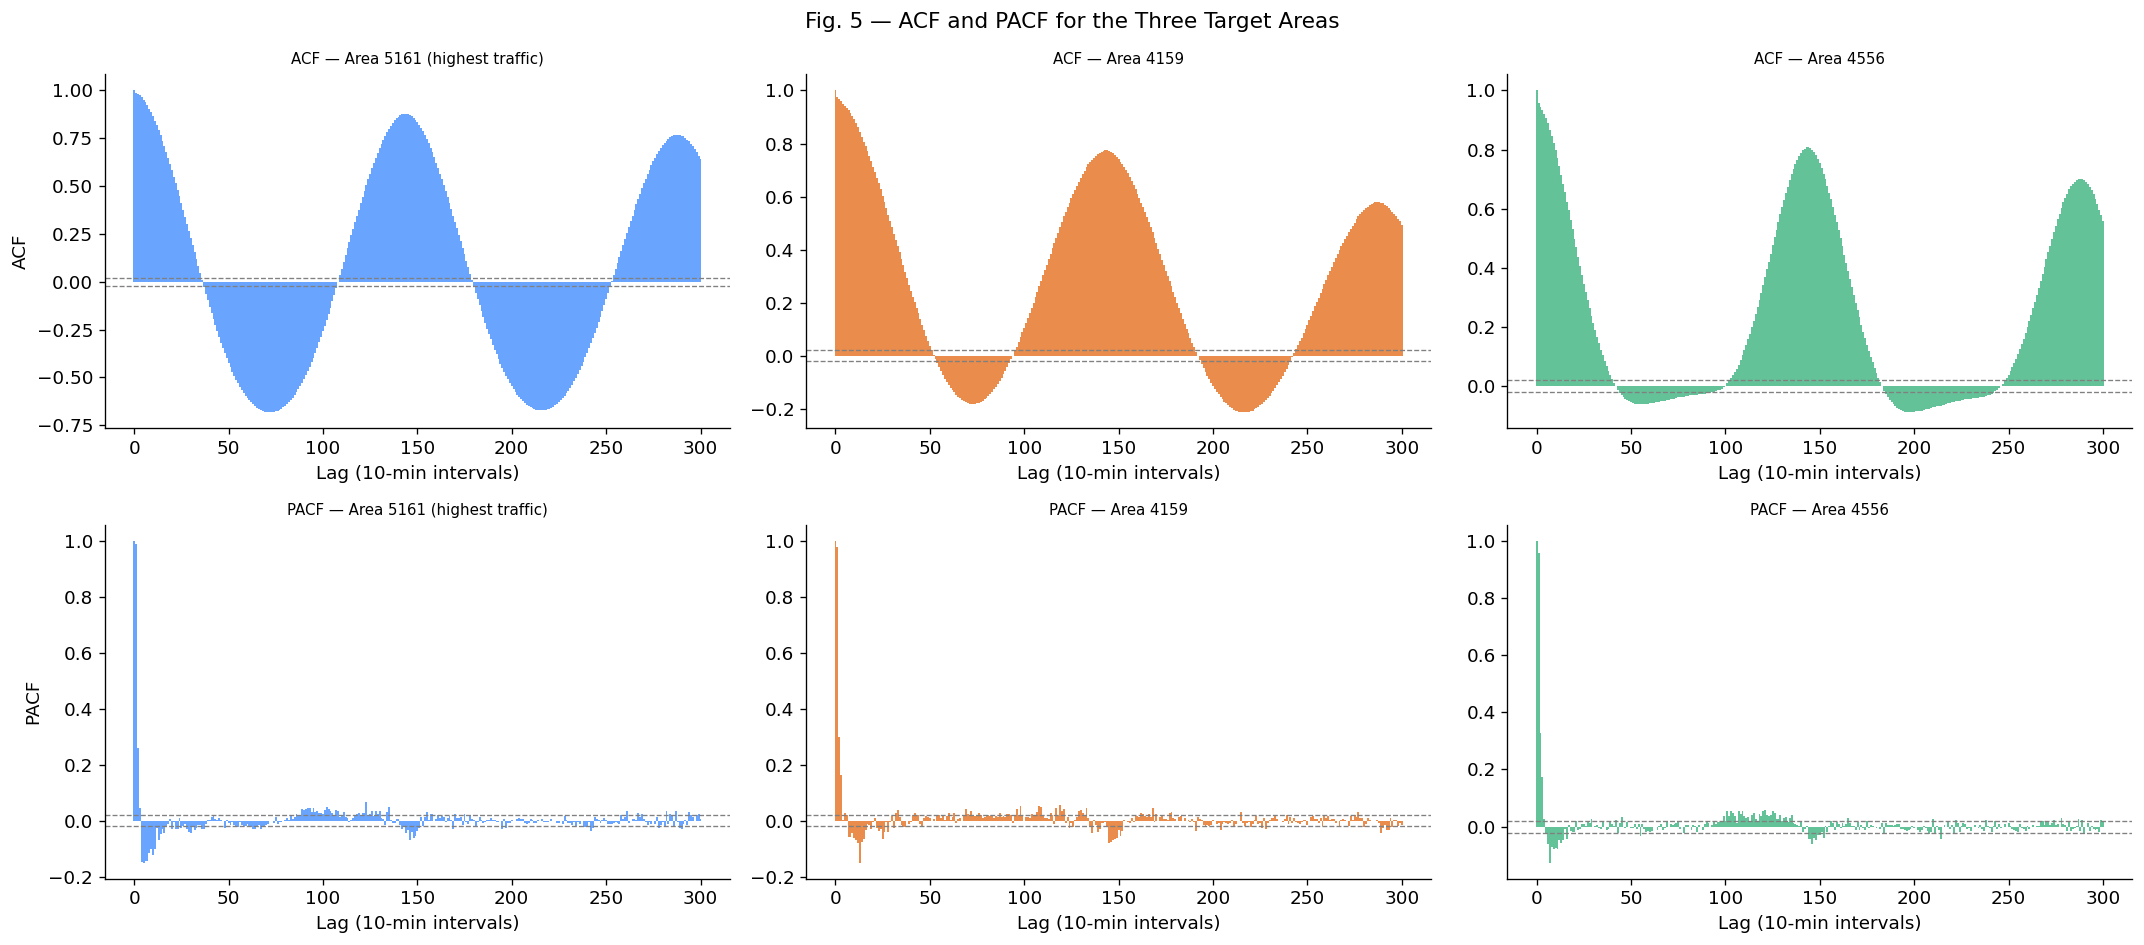

Peak ACF lags (>0.3):
  Area 5161 (highest traffic): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Area 4159: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Area 4556: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [6]:
NLAGS = 300   # ~50 hours

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for col_idx, sq in enumerate(TARGET_AREAS):
    s = series_dict[sq].values
    acf_vals  = acf(s,  nlags=NLAGS, fft=True)
    pacf_vals = pacf(s, nlags=min(NLAGS, len(s)//2 - 1), method="ywm")

    lag_axis = np.arange(len(acf_vals))
    ci = 1.96 / np.sqrt(len(s))

    ax_acf  = axes[0, col_idx]
    ax_pacf = axes[1, col_idx]

    ax_acf.bar(lag_axis, acf_vals, color=colors[col_idx], alpha=0.7, width=1)
    ax_acf.axhline( ci, color="gray", ls="--", lw=0.8)
    ax_acf.axhline(-ci, color="gray", ls="--", lw=0.8)
    ax_acf.set_title(f"ACF — {AREA_LABELS[sq]}", fontsize=9)
    ax_acf.set_xlabel("Lag (10-min intervals)")

    ax_pacf.bar(np.arange(len(pacf_vals)), pacf_vals,
                color=colors[col_idx], alpha=0.7, width=1)
    ax_pacf.axhline( ci, color="gray", ls="--", lw=0.8)
    ax_pacf.axhline(-ci, color="gray", ls="--", lw=0.8)
    ax_pacf.set_title(f"PACF — {AREA_LABELS[sq]}", fontsize=9)
    ax_pacf.set_xlabel("Lag (10-min intervals)")

axes[0, 0].set_ylabel("ACF")
axes[1, 0].set_ylabel("PACF")
fig.suptitle("Fig. 5 — ACF and PACF for the Three Target Areas", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "fig05_acf_pacf.png", bbox_inches="tight")
plt.show()

print("Peak ACF lags (>0.3):")
for sq in TARGET_AREAS:
    av = acf(series_dict[sq].values, nlags=NLAGS, fft=True)
    peaks = [i for i, v in enumerate(av[1:], 1) if abs(v) > 0.3]
    print(f"  {AREA_LABELS[sq]}: {peaks[:10]}")

**Interpretation.** The ACF shows significant positive correlations at multiples of **lag 144** (= one day), confirming the 24-hour periodicity already visible in the raw series. The PACF decays quickly after the first few lags, suggesting that a small number of recent lags explain most of the serial dependence — this informs the sequence-length choice for the neural models in Task 3. The recurring ACF spikes also suggest that a seasonal ARIMA model with a seasonal period of 144 is a natural statistical baseline.

## 2.6 Spatial Analysis — Traffic Heatmap

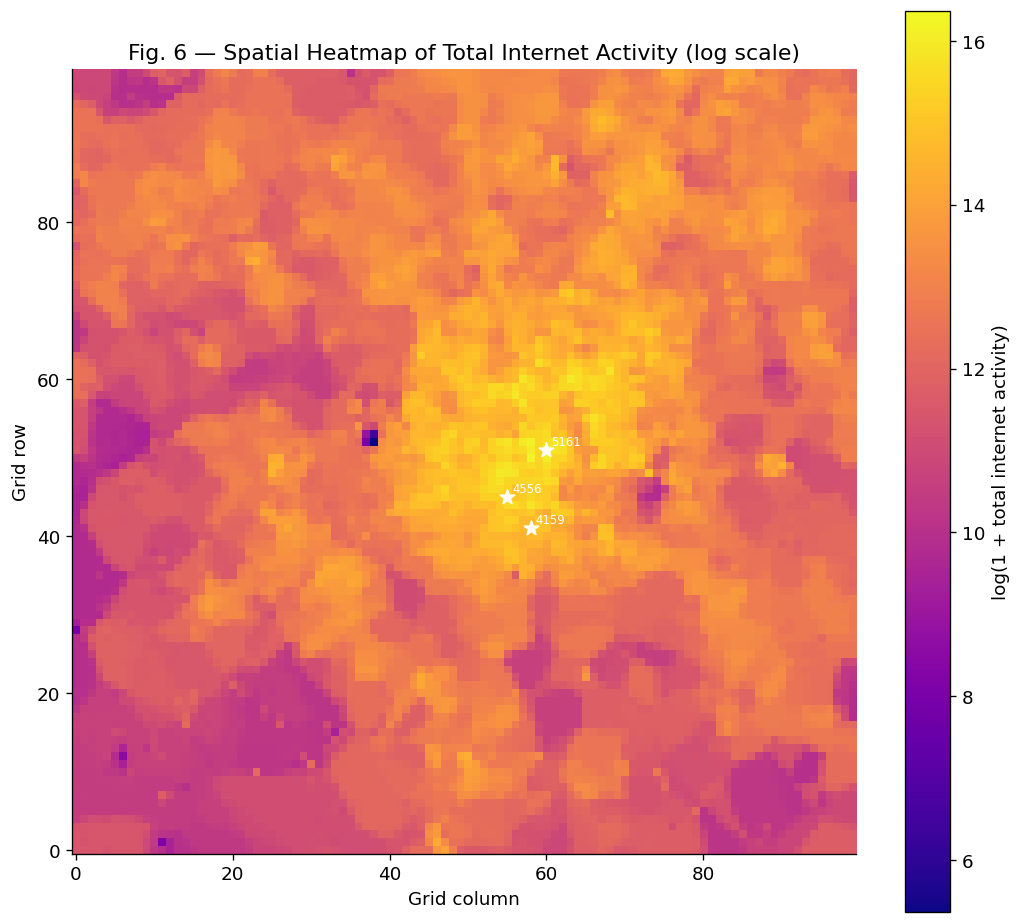

In [7]:
# Build 100x100 grid totals
total_per_square["row"] = ((total_per_square["square_id"] - 1) // 100).astype(int)
total_per_square["col"] = ((total_per_square["square_id"] - 1) % 100).astype(int)

grid = np.zeros((100, 100), dtype=np.float64)
for _, r in total_per_square.iterrows():
    grid[int(r["row"]), int(r["col"])] = r["total_traffic"]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(np.log1p(grid), cmap="plasma", origin="lower", aspect="equal")
plt.colorbar(im, ax=ax, label="log(1 + total internet activity)")

# Mark the three target areas
for sq in TARGET_AREAS:
    r = (sq - 1) // 100
    c = (sq - 1) % 100
    ax.scatter(c, r, s=80, marker="*", color="white", zorder=5)
    ax.annotate(str(sq), (c, r), color="white", fontsize=7,
                xytext=(3, 3), textcoords="offset points")

ax.set_title("Fig. 6 — Spatial Heatmap of Total Internet Activity (log scale)")
ax.set_xlabel("Grid column")
ax.set_ylabel("Grid row")
plt.tight_layout()
plt.savefig(FIGURES / "fig06_heatmap.png", bbox_inches="tight")
plt.show()

**Interpretation.** The heatmap reveals a strong spatial concentration: the brightest cells form a cluster near the city centre (the Duomo/central business district), with satellite hot-spots corresponding to transportation nodes (railway stations, highways). Peripheral squares are predominantly dark, reflecting residential or rural areas with lower mobile usage density. This spatial heterogeneity validates the decision to select one high-traffic area alongside two moderate areas as the three evaluation targets.

## 2.7 Anomaly Detection

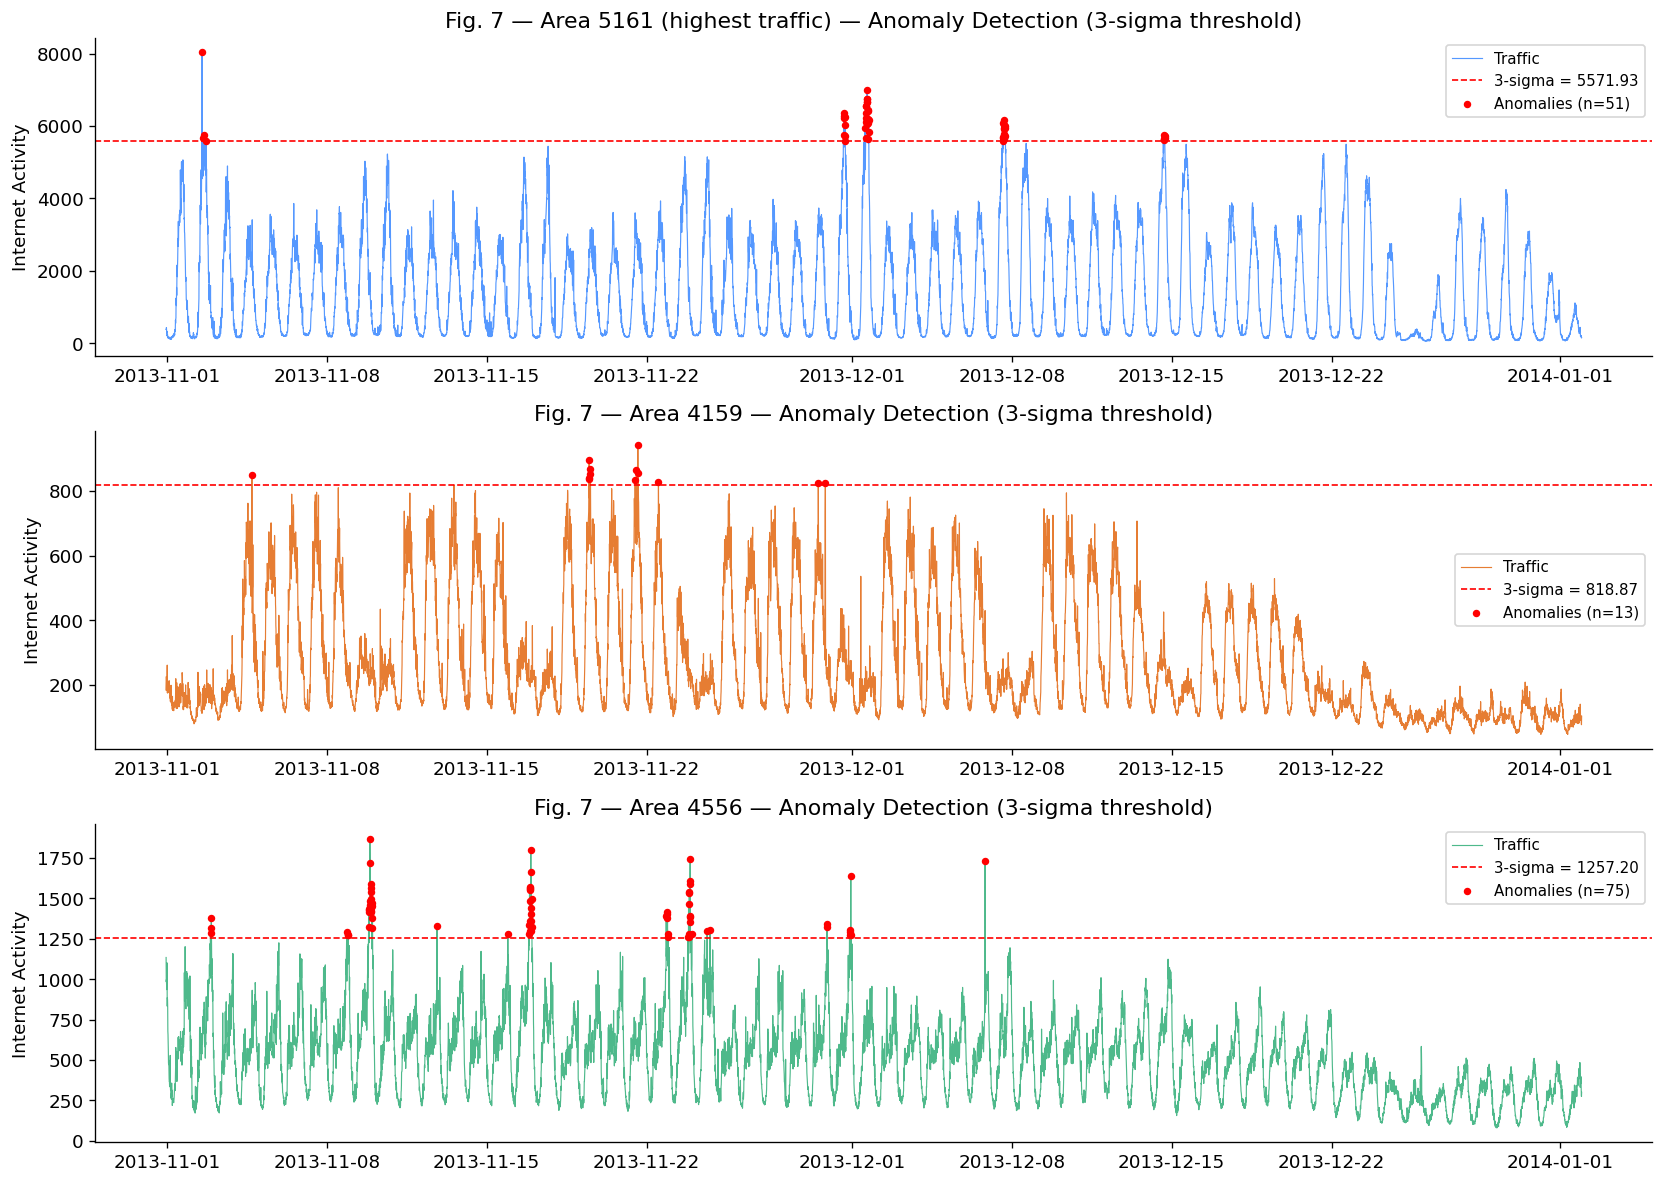

Area  5161: 51 anomalous intervals  (threshold=5571.925)
Area  4159: 13 anomalous intervals  (threshold=818.867)
Area  4556: 75 anomalous intervals  (threshold=1257.198)


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

anomaly_records = []

for ax, sq, col in zip(axes, TARGET_AREAS, colors):
    s = series_dict[sq]
    mu, sigma = s.mean(), s.std()
    threshold  = mu + 3 * sigma
    anomalies  = s[s > threshold]

    ax.plot(s.index, s.values, color=col, lw=0.7, alpha=0.8, label="Traffic")
    ax.axhline(threshold, color="red", ls="--", lw=1.0, label=f"3-sigma = {threshold:.2f}")
    ax.scatter(anomalies.index, anomalies.values,
               color="red", s=12, zorder=5, label=f"Anomalies (n={len(anomalies)})")
    ax.set_title(f"Fig. 7 — {AREA_LABELS[sq]} — Anomaly Detection (3-sigma threshold)")
    ax.set_ylabel("Internet Activity")
    ax.legend(fontsize=9)
    anomaly_records.append({"area": sq, "n_anomalies": len(anomalies),
                             "threshold": threshold})

plt.tight_layout()
plt.savefig(FIGURES / "fig07_anomalies.png", bbox_inches="tight")
plt.show()

for r in anomaly_records:
    print(f"Area {r['area']:5d}: {r['n_anomalies']} anomalous intervals  (threshold={r['threshold']:.3f})")

**Interpretation.** Anomalous intervals (> 3 standard deviations above the mean) are sparse but consistent with known events in Milan during the study period: the city hosted a major football match (Serie A rounds fall on weekends) and the Christmas/New Year festivities in late December produced abnormally high mobile usage. These episodes correspond to the highest-amplitude spikes observed in the residual component of the decomposition. Such anomalies constitute **failure cases** for the forecasting models, which are explored further in Task 3.

## 2.8 Summary of Target Areas

The analysis confirms the three areas capture meaningfully different traffic regimes, making them ideal evaluation targets.

In [9]:
summary = []
for sq in TARGET_AREAS:
    s = series_dict[sq]
    summary.append({
        "Square": sq,
        "Label": AREA_LABELS[sq],
        "Total traffic": f"{s.sum():.1f}",
        "Mean (10-min)": f"{s.mean():.3f}",
        "Std": f"{s.std():.3f}",
        "Max": f"{s.max():.3f}",
        "% zeros": f"{(s == 0).mean()*100:.1f}%",
    })

pd.DataFrame(summary).set_index("Square")

# Save target area IDs for downstream notebooks
import json
(BASE / "processed" / "target_areas.json").write_text(
    json.dumps({"top_square": top_square, "areas": TARGET_AREAS})
)
print(f"Target areas saved: {TARGET_AREAS}")

Target areas saved: [5161, 4159, 4556]
